In [ ]:
#step 1:Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
# step 2:Load Dataset

fake_df = pd.read_csv("/content/Fake.csv")
true_df = pd.read_csv("/content/True.csv")

print("Fake Dataset Shape :", fake_df.shape)
print("True Dataset Shape :", true_df.shape)

display(fake_df.head())

display(true_df.head())

Fake Dataset Shape : (23481, 4)
True Dataset Shape : (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
#step 3: Check missing values in Fake dataset
print("Missing values in Fake Dataset:")
print(fake_df.isnull().sum())

# Check missing values in True dataset
print("\nMissing values in True Dataset:")
print(true_df.isnull().sum())

Missing values in Fake Dataset:
title      0
text       0
subject    0
date       0
dtype: int64

Missing values in True Dataset:
title      0
text       0
subject    0
date       0
dtype: int64


In [ ]:
#step 4:Display Sample Data
fake_df.head()
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
#step 5:check dataset information
fake_df.info()
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [ ]:
# step 6:check duplicates value
print("Fake Duplicate:", fake_df.duplicated().sum())
print("True Duplicate:", true_df.duplicated().sum())

Fake Duplicate: 3
True Duplicate: 206


In [ ]:
#step 7:remove duplicates
fake_df = fake_df.drop_duplicates()
true_df = true_df.drop_duplicates()

In [ ]:
#step 8:add labels
fake_df["label"] = 0
true_df["label"] = 1

In [ ]:
#step 9:merge both dataset
df = pd.concat([fake_df, true_df], ignore_index=True)
print(df.shape)

(44689, 5)


In [ ]:
#step 10:shuffle dataset
df = df.sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)

In [ ]:
#step 11:check final dataset
df.head()

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0


In [ ]:
#step 12:check final dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44689 non-null  object
 1   text     44689 non-null  object
 2   subject  44689 non-null  object
 3   date     44689 non-null  object
 4   label    44689 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [ ]:
#step 13:check missing value
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
#step 14:Dataset description
df.describe(include="all")

,title,text,subject,date,label
count,44689,44689,44689,44689,44689.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 6, 2017",NaN
freq,14,627,11220,166,NaN
mean,NaN,NaN,NaN,NaN,0.474636
std,NaN,NaN,NaN,NaN,0.499362
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


In [ ]:
#step 15:Check classs distribution
df["label"].value_counts()

,count
label,
0,23478
1,21211


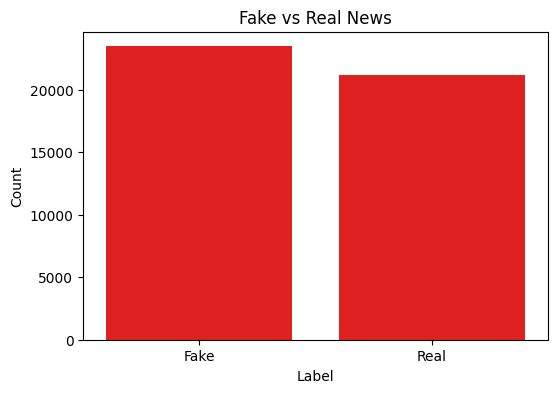

In [ ]:
#step 16:plot fake vs real news
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df,color='red')

plt.xlabel("Label")

plt.ylabel("Count")

plt.title("Fake vs Real News")

plt.xticks([0,1],["Fake","Real"])

plt.show()

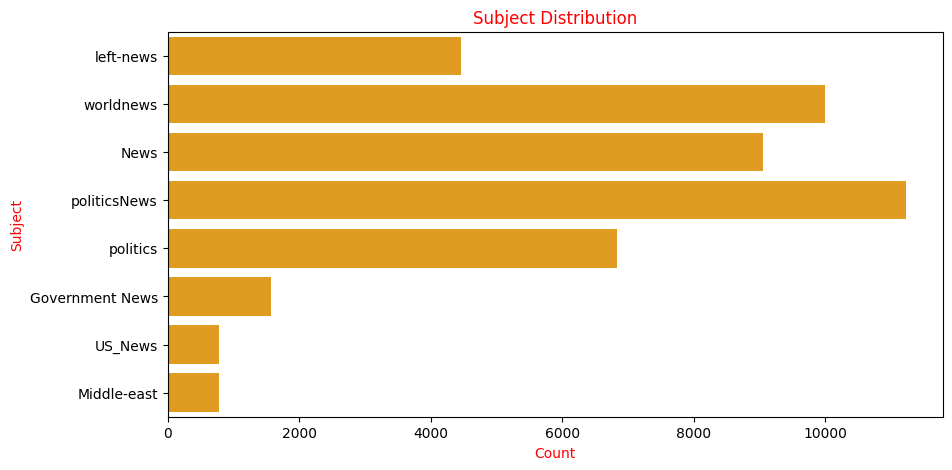

In [ ]:
#step 17:subject Distribution
plt.figure(figsize=(10,5))

sns.countplot(y="subject", data=df,color='orange')

plt.xlabel("Count",color='red')

plt.ylabel("Subject",color='red')

plt.title("Subject Distribution",color='red')

plt.show()

In [ ]:
#step 18:News Length
df["text_length"] = df["text"].apply(len)

df["text_length"].head()

,text_length
0,10062
1,2808
2,232
3,610
4,2658


In [ ]:
#step 19:statistics of news length
df["text_length"].describe()

,text_length
count,44689.000000
mean,2467.098682
std,2173.612347
min,1.000000
25%,1232.000000
50%,2185.000000
75%,3101.000000
max,51794.000000


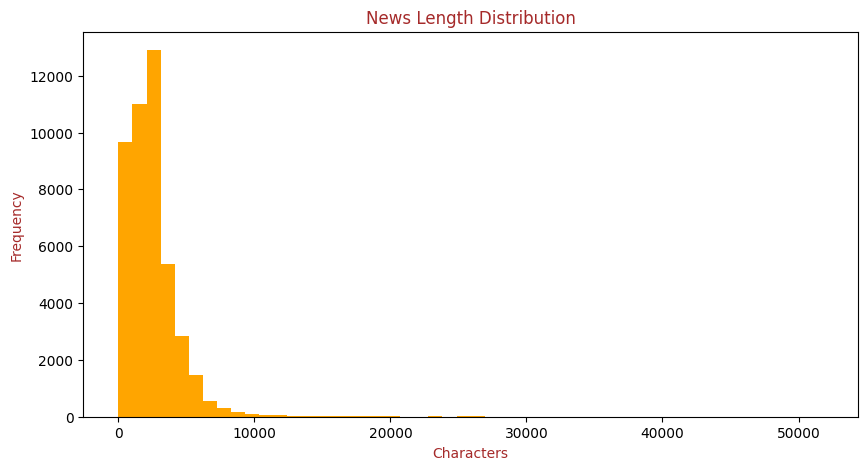

In [ ]:
#step 20:Histogram
plt.figure(figsize=(10,5))

plt.hist(df["text_length"], bins=50,color='orange')

plt.xlabel("Characters",color='brown')

plt.ylabel("Frequency",color='brown')

plt.title("News Length Distribution",color='brown')

plt.show()

In [ ]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'text_length'], dtype='object')


In [ ]:
#step 21:Create the clean_text column
import re
import string
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_news(text):
    text = str(text).lower()                     # Convert to lowercase
    text = re.sub(r'http\S+', '', text)          # Remove URLs
    text = re.sub(r'<.*?>', '', text)            # Remove HTML tags
    text = re.sub(r'\d+', '', text)              # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]        # Remove stopwords
    return " ".join(words)

# Create cleaned text column
df["clean_text"] = df["text"].apply(clean_news)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#verify
df[["text", "clean_text"]].head()

,text,clean_text
0,"A school librarian in Cambridge, Massachusetts...",school librarian cambridge massachusetts rejec...
1,NAIROBI (Reuters) - Kenyan opposition leader R...,nairobi reuters kenyan opposition leader raila...
2,CAIRO (Reuters) - Egypt rejected the U.S. deci...,cairo reuters egypt rejected us decision move ...
3,After a recent speech given by Minister Louis ...,recent speech given minister louis farrakhan t...
4,Tensions ran high outside of a campaign rally ...,tensions ran high outside campaign rally donal...


In [ ]:
#TF-IDF
X = df["clean_text"]
y = df["label"]

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [ ]:
#SPLIT THE DATASET
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#ALGORITHM 1: LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
lr_model = LogisticRegression(max_iter=1000)

# Train Model
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9892593421347058

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4670
           1       0.98      0.99      0.99      4268

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938


Confusion Matrix
[[4600   70]
 [  26 4242]]


In [ ]:
#ALGORITHM 2:NAIVE BAYES
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print(classification_report(y_test, y_pred_nb))

print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9488699932870889
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4670
           1       0.93      0.96      0.95      4268

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938

[[4376  294]
 [ 163 4105]]


In [ ]:
#ALGORITHM 3:DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9961960170060417
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4670
           1       1.00      1.00      1.00      4268

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938

[[4657   13]
 [  21 4247]]


In [ ]:
#ALGORITHM 4:RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9975385992392034
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4670
           1       1.00      1.00      1.00      4268

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938

[[4653   17]
 [   5 4263]]


             Algorithm  Accuracy
0  Logistic Regression  0.989259
1          Naive Bayes  0.948870
2        Decision Tree  0.996196
3        Random Forest  0.997539


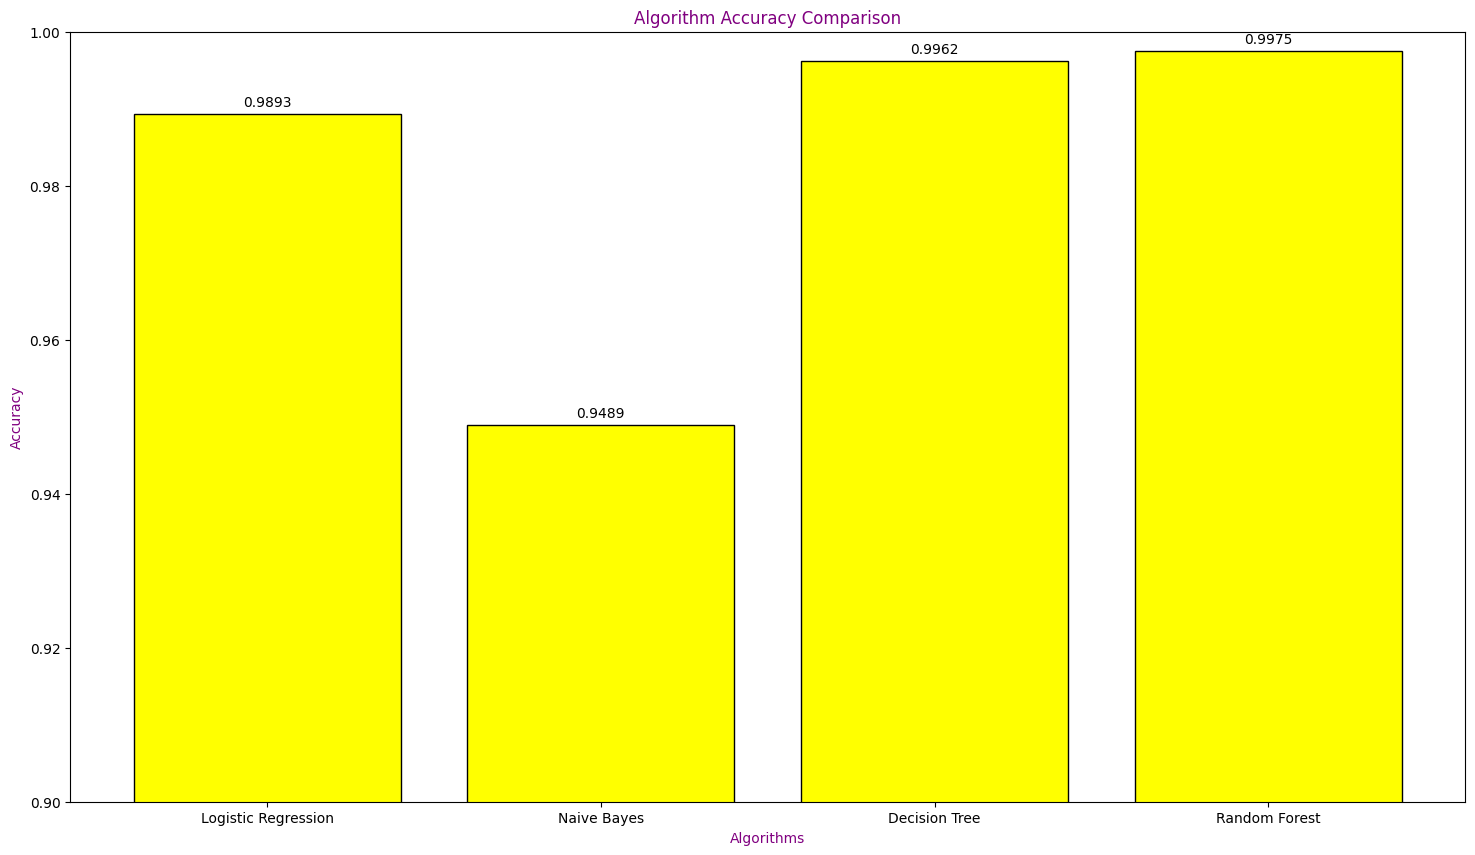

In [ ]:
#COMPARE ALL ALGORITHM
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "Algorithm": [
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.9892593421347058,
        0.9488699932870889,
        0.9961960170060417,
        0.9975385992392034
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(18,10))
plt.bar(results_df["Algorithm"], results_df["Accuracy"],color='yellow',edgecolor='black')
plt.title("Algorithm Accuracy Comparison",color='purple')
plt.xlabel("Algorithms",color='purple')
plt.ylabel("Accuracy",color='purple')
plt.ylim(0.90, 1.00)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value + 0.001, f"{value:.4f}", ha='center')

plt.show()

In [ ]:
#Save the Best Model
import pickle

# Save Random Forest Model
with open("fake_news_model.pkl", "wb") as model_file:
    pickle.dump(rf_model, model_file)

# Save TF-IDF Vectorizer
with open("tfidf_vectorizer.pkl", "wb") as vectorizer_file:
    pickle.dump(tfidf, vectorizer_file)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


In [ ]:
news = """
The government announced a new policy to improve education across the country.
"""

news_clean = clean_news(news)

news_vector = tfidf.transform([news_clean])

prediction = rf_model.predict(news_vector)

if prediction[0] == 0:
    print("Prediction: Fake News")
else:
    print("Prediction: Real News")




Prediction: Fake News
